# **Examining Occupational Stereotypes (Ngrams)**
## **Goal**: Test relationships between occupational demographics and professions' feminization–masculinization.

### **Setup**
#### Imports

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

from ngramprep.common.w2v_model import W2VModel
from analyze.cosine_similarity_time_series import cosine_similarity_over_years, plot_nearest_neighbors
from analyze.weat_time_series import compute_weat_over_years
from analyze.dimension_projection_time_series import compute_projection_over_years, compute_baseline_set
from analyze.pca_dimension_time_series import compute_pca_dimension_over_years
from analyze.semantic_drift import (
    track_local_semantic_change,
    track_global_semantic_change,
    track_directional_drift,
)
from analyze.average_relatedness_by_year import track_word_relatedness
from analyze.ipums.ipums_utils import (
    aggregate_ipums_professions_csv,
    aggregate_ipums_professions_csv_batch,
    fetch_and_aggregate_ipums_professions_csv,
    fetch_ipums_microdata_cps,
    calculate_women_percentage,
)
from analyze.ipums.correlation_analysis import run_correlation_analysis
from analyze.ipums.build_panel import build_panel
from ipumspy import IpumsApiClient, MicrodataExtract

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Configure

In [2]:
model_path =  '/scratch/edk202/NLP_models/Google_Books/20200217/eng-fiction/5gram_files/models_final/norm_and_align'
bin_size = 2

### **Generate gender projection**
#### Use the `compute_meandiff_dimension` method to create a masculinization dimension

In [3]:
year = 2018
model = W2VModel(f'{model_path}/w2v_y{year}_wbnone_vs300_w004_mc001_sg1_e010.kv')

gender_contrasts = [
    ('she', 'he'),
    ('her', 'his'),
    ('herself', 'himself'),
    ('woman', 'man'),
    ('women', 'men'),
    ('girl', 'boy'),
    ('girls', 'boys'),
    ('mother', 'father'),
    ('mothers', 'fathers'),
    ('daughter', 'son'),
    ('daughters', 'sons'),
    ('sister', 'brother'),
    ('sisters', 'brothers')
]

meandiff_result = model.compute_meandiff_dimension(
    token_contrasts=gender_contrasts
)

#### Print various words' projections on the masculinization dimension using the `print_word_projections` method

In [4]:
test_words = [
    # Clear anchors
    'husband', 'wife',
    'king', 'queen',

    # Historically masculine-stereotyped professions
    'engineer', 'physicist', 'soldier', 'pilot',
    'firefighter', 'mechanic', 'carpenter',
    'programmer', 'CEO', 'president',
    'construction_worker', 'plumber',

    # Historically feminine-stereotyped professions
    'nurse', 'teacher', 'secretary', 'receptionist',
    'librarian', 'babysitter', 'housekeeper',
    'caregiver', 'assistant', 'hairdresser',

    # Leadership / status roles (interesting test cases)
    'leader', 'manager', 'chairperson',
    'lawyer', 'doctor', 'scientist',
    'professor', 'judge',

    # Trait terms (useful for validating axis content)
    'strong', 'assertive', 'dominant',
    'competitive', 'logical', 'independent',
    'gentle', 'nurturing', 'empathetic',
    'emotional', 'supportive', 'caring'
]

projections = W2VModel.print_word_projections(model, meandiff_result['dimension'], test_words)


────────────────────────────────────────────────────────────────────────────────────────────────────
WORD PROJECTIONS ON DIMENSION
────────────────────────────────────────────────────────────────────────────────────────────────────
Word                           Projection                                           Visualization
────────────────────────────────────────────────────────────────────────────────────────────────────
  king                             0.1752                                               █████
  soldier                          0.1740                                               █████
  pilot                            0.1543                                                ████
  leader                           0.1316                                                 ███
  physicist                        0.1187                                                 ███
  president                        0.1180                                                 ███
  me

### **Examine time-series**
#### Auto-generate a baseline trend using `compute_baseline_set` function

Using shared vocabulary: 25538 words found across all models

Baseline word set selection:
  Total vocabulary:          25,538
  Neutral candidates:        24,631 (after anchor & pattern exclusion)
  Selected neutral words:    22,027 (passed stability thresholds)

  Selection thresholds:
    |mu| < 0.080  (mean projection)
    |beta| < 0.0100  (trend/year)
    sigma < 0.150  (temporal variability)
    n >= 5  (minimum years)

  Neutral word statistics:
    Mean |mu|:     0.0306
    Mean |beta|:   0.0007
    Mean sigma:    0.0357

  Over-time correlation:
    Mean:          0.5035
    Median:        0.4880
    Std:           0.0927
    Range:         [0.3706, 0.8202]

  Aggregation:               mean



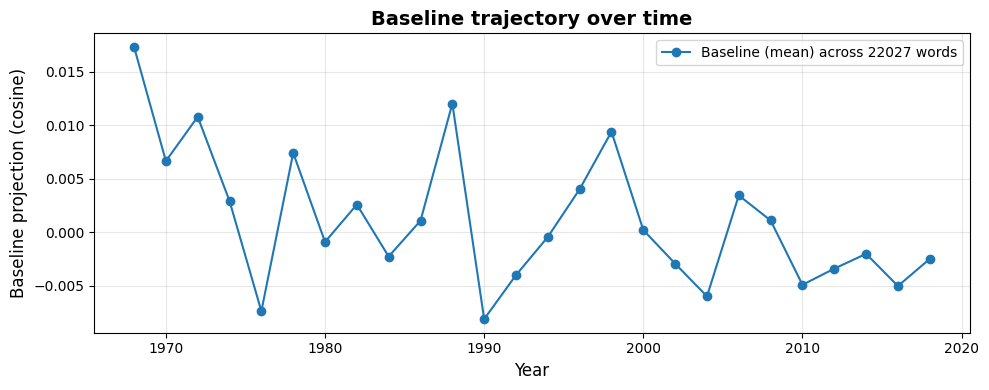

In [5]:
baseline_source = compute_baseline_set(
    model_dir=model_path,
    contrast_pairs=gender_contrasts,
    start_year=1968,
    end_year=2018,
    year_step=1,
    method='meandiff',
    exclusion_pattern=r"(man|men|woman|women|girl|boy|girls|boys|mother|father|mothers|fathers|daughter|son|daughters|sons|sister|brother)",
    eps_mean=0.08,
    eps_trend=0.010,
    eps_sigma=0.15,
    min_years=5,
    agg="mean",
    corr_n_permutations=0,
    verbose=True,
    plot_baseline=True
)

baseline_source = baseline_source["baseline"]

#### Alternatively, specify a set of baseline words

In [6]:
baseline_source = [
    'table', 'chair', 'window', 'door', 'wall', 'floor', 'roof', 'tree', 'leaf', 'branch', 'root', 'flower',
    'grass', 'water', 'stone', 'rock', 'sand', 'soil', 'clay', 'book', 'page', 'paper', 'pen', 'ink', 'cup',
    'plate', 'bowl', 'spoon', 'knife', 'fork', 'bread', 'cheese', 'butter', 'salt', 'sugar', 'road', 'path',
    'bridge', 'gate', 'fence', 'box', 'bag', 'basket', 'bottle', 'jar', 'horse', 'cow', 'sheep', 'pig',
    'chicken', 'dog', 'cat', 'sun', 'moon', 'star', 'cloud', 'rain', 'wind', 'river', 'lake', 'mountain',
    'hill', 'valley', 'wood', 'metal', 'iron', 'gold', 'silver', 'wheel', 'rope', 'chain', 'nail', 'hammer'
]

#### Specify the set of occupations from Caliskan et al. (2017)

In [7]:
targets = [
    "technician", "accountant", "supervisor", "engineer", "worker", "educator", "clerk", "counselor",
    "inspector", "mechanic", "manager", "therapist", "administrator", "salesperson", "receptionist", "librarian",
    "advisor", "pharmacist", "janitor", "psychologist", "physician", "carpenter", "nurse", "investigator",
    "bartender", "specialist", "electrician", "officer", "pathologist", "teacher", "lawyer", "planner",
    "practitioner", "plumber", "instructor", "surgeon", "veterinarian", "paramedic", "examiner", "chemist",
    "machinist", "appraiser", "nutritionist", "architect", "hairdresser", "baker", "programmer", "paralegal",
    "hygienist", "scientist"
]

#### Compute and plot masculinization time-series

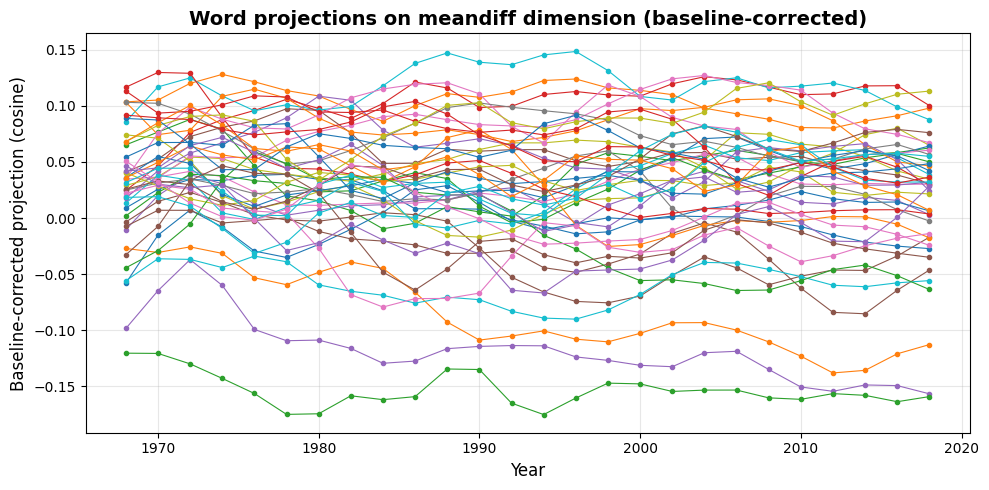

In [8]:
result = compute_projection_over_years(
    model_dir=model_path,
    token_contrasts=gender_contrasts,
    test_words=targets,
    start_year=1968,
    end_year=2018,
    year_step=2,
    method='meandiff',
    ensure_sign_positive=True,
    smooth=True,
    sigma=1,
    verbose=False,
    baseline_source=baseline_source,
    plot_corrected_if_baseline=True,
    plot=True,
 )

### **IPUMS workflow**
#### Live IPUMS CPS ASEC download

Fetches the most recent CPS ASEC extract with harmonized occupation codes (`OCC2010`) and person weights (`ASECWT`).
Auto-discovers the latest ASEC sample, submits/waits/downloads, and decompresses `.gz` files in place.

In [9]:
result_df = fetch_and_aggregate_ipums_professions_csv(
    occupation_map_file='/scratch/edk202/lexichron/ipums_occ2010_map.csv',
    api_key='59cba10d8a5da536fc06b59d0d34a8b208154b9684e7d4fadbe0a339',
    years=range(1968, 2026),
    overwrite=False,
    download_dir='/scratch/edk202/lexichron/ipums_api_downloads'
)

overwrite=False: Using 58 existing file(s) from /scratch/edk202/lexichron/ipums_api_downloads
  - professionsIPUMS_1968.csv (206 rows)
  - professionsIPUMS_1969.csv (205 rows)
  - professionsIPUMS_1970.csv (205 rows)
  ... and 55 more


Using IPUMS data: /scratch/edk202/lexichron/ipums_api_downloads/professionsIPUMS_2014.csv
Matched 46/50 professions in IPUMS data
Using baseline-corrected projections
Valid professions (non-NaN projections): 40 out of 46
Filtered out 6 professions with NaN projections

=== Correlation Results (Baseline-corrected) ===
Pearson r = -0.5820
p-value = 0.000082
n = 40 professions


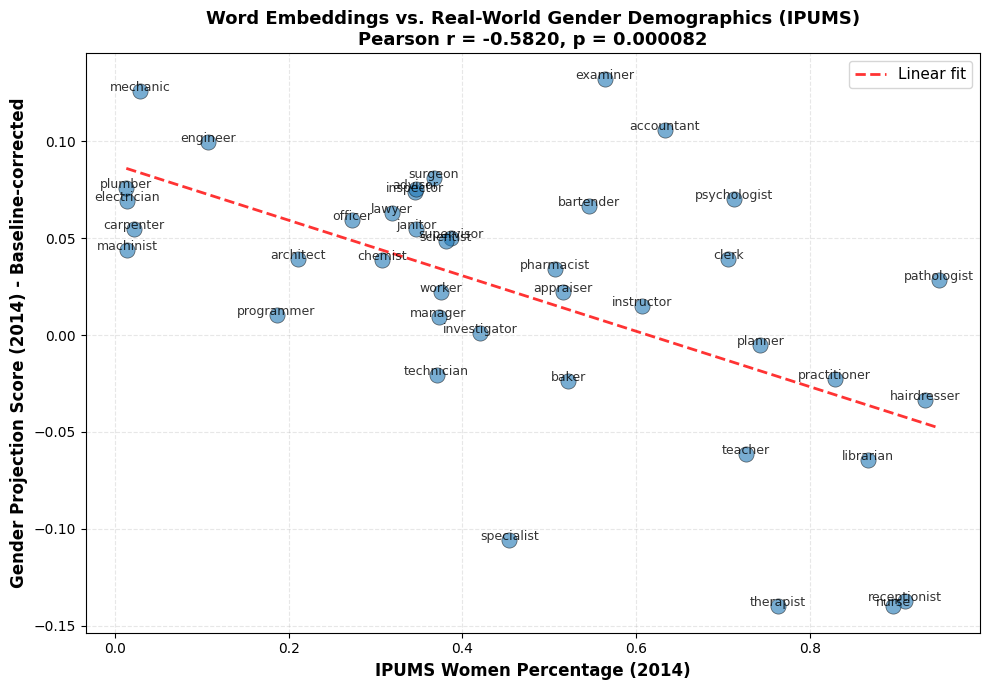


✓ Significant correlation (p < 0.05)


In [10]:
run_correlation_analysis(
    year_of_interest=2014,
    use_baseline_corrected=True,
    targets=targets,
    result_df=result_df,
    result=result,
    calculate_women_percentage=calculate_women_percentage
)

In [11]:
panel_df = build_panel(
    result=result,
    result_df=result_df,
    targets=targets,
    calculate_women_percentage=calculate_women_percentage,
    use_baseline_corrected_panel=True,
    bin_size=bin_size
)

panel_df.head(10)

,profession,year,women_pct,projection
0,technician,1968,0.124779,-0.007211
1,accountant,1968,0.225500,0.113243
2,supervisor,1968,0.075806,0.057827
3,engineer,1968,0.007892,0.016691
4,worker,1968,0.273150,-0.039315
5,clerk,1968,0.667355,0.038953
6,inspector,1968,0.464000,0.037160
7,mechanic,1968,0.003123,0.043316
8,manager,1968,0.149087,-0.101398
9,therapist,1968,0.660500,-0.016685


#### Random-Intercept Cross-Lagged Panel Model (RI-CLPM)

Separates stable between-profession differences (random intercepts) from within-profession dynamics:
- Autoregressive paths: `women_pct(t) → women_pct(t+1)` and `projection(t) → projection(t+1)`
- Cross-lagged paths: `women_pct(t) → projection(t+1)` and `projection(t) → women_pct(t+1)`

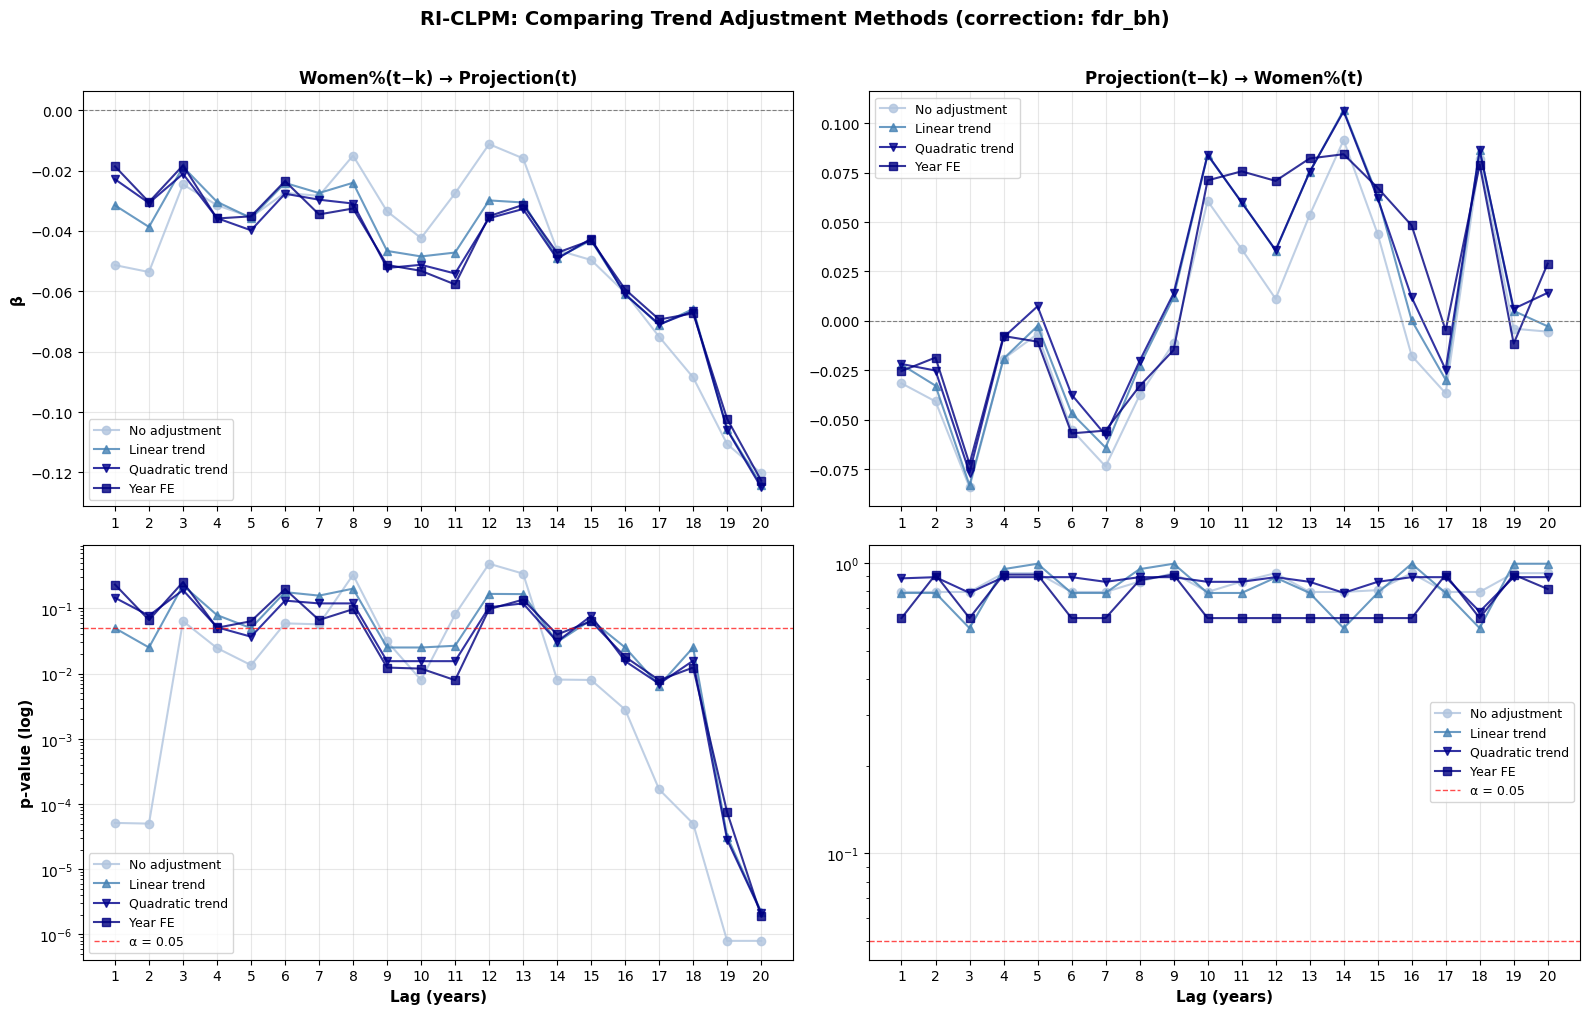


SUMMARY: Significant lags (adjusted p < 0.05) | Correction: fdr_bh
No adjustment       : W→P sig at 13/20 lags [1, 2, 4, 5, 9, 10, 14, 15, 16, 17, 18, 19, 20]
                      P→W sig at  0/20 lags []
Linear trend        : W→P sig at 12/20 lags [1, 2, 5, 9, 10, 11, 14, 16, 17, 18, 19, 20]
                      P→W sig at  0/20 lags []
Quadratic trend     : W→P sig at 10/20 lags [5, 9, 10, 11, 14, 16, 17, 18, 19, 20]
                      P→W sig at  0/20 lags []
Year FE             : W→P sig at  9/20 lags [9, 10, 11, 14, 16, 17, 18, 19, 20]
                      P→W sig at  0/20 lags []

------------------------------------------------------------------------------------------
YEAR FE MODEL DETAILS (correction: fdr_bh)
------------------------------------------------------------------------------------------
 Lag     n     β(W→P)    p_raw    p_adj  sig     β(P→W)    p_raw    p_adj  sig
──────────────────────────────────────────────────────────────────────────────────────────
   1

In [24]:
import statsmodels.formula.api as smf
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.stats.multitest import multipletests

# RI-CLPM lag sweep: compare different trend adjustment approaches
# 1. No trend adjustment (baseline)
# 2. Year fixed effects (non-parametric, absorbs all shared period effects)
# 3. Linear time trend (parsimonious, assumes smooth secular change)
# 4. Quadratic time trend (allows curvature)

# === PARAMETERS ===
lag_range = range(1, 21)
alpha = 0.05
correction_method = 'fdr_bh'  # Options: None, 'bonferroni', 'holm', 'fdr_bh', 'fdr_by'
# ===================

results = {'none': [], 'year_fe': [], 'linear': [], 'quadratic': []}

panel_sorted = panel_df.sort_values(['profession', 'year']).copy()
panel_sorted['time_trend'] = panel_sorted['year'] - panel_sorted['year'].min()
panel_sorted['time_trend_sq'] = panel_sorted['time_trend'] ** 2

# Pre-compute all lagged columns
for lag_k in lag_range:
    panel_sorted[f'women_pct_lag{lag_k}'] = panel_sorted.groupby('profession')['women_pct'].shift(lag_k)
    panel_sorted[f'projection_lag{lag_k}'] = panel_sorted.groupby('profession')['projection'].shift(lag_k)

# Fit models for each lag
for lag_k in lag_range:
    wp_lag = f'women_pct_lag{lag_k}'
    proj_lag = f'projection_lag{lag_k}'
    
    df_k = panel_sorted.dropna(subset=[wp_lag, proj_lag]).copy()
    if len(df_k) < 20:
        continue
    
    formulas = {
        'none': (
            f"projection ~ {proj_lag} + {wp_lag}",
            f"women_pct ~ {wp_lag} + {proj_lag}"
        ),
        'year_fe': (
            f"projection ~ {proj_lag} + {wp_lag} + C(year)",
            f"women_pct ~ {wp_lag} + {proj_lag} + C(year)"
        ),
        'linear': (
            f"projection ~ {proj_lag} + {wp_lag} + time_trend",
            f"women_pct ~ {wp_lag} + {proj_lag} + time_trend"
        ),
        'quadratic': (
            f"projection ~ {proj_lag} + {wp_lag} + time_trend + time_trend_sq",
            f"women_pct ~ {wp_lag} + {proj_lag} + time_trend + time_trend_sq"
        ),
    }
    
    for model_type, (f1, f2) in formulas.items():
        try:
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", category=ConvergenceWarning)
                m1 = smf.mixedlm(f1, data=df_k, groups=df_k["profession"]).fit(disp=False)
                m2 = smf.mixedlm(f2, data=df_k, groups=df_k["profession"]).fit(disp=False)
            
            results[model_type].append({
                'lag': lag_k,
                'n_obs': len(df_k),
                'beta_w2p': m1.fe_params[wp_lag],
                'se_w2p': m1.bse[wp_lag],
                'p_w2p': m1.pvalues[wp_lag],
                'beta_p2w': m2.fe_params[proj_lag],
                'se_p2w': m2.bse[proj_lag],
                'p_p2w': m2.pvalues[proj_lag],
            })
        except Exception as e:
            print(f"  Lag {lag_k}, {model_type}: failed ({e})")

# Convert to DataFrames and apply correction
result_dfs = {}
for k, v in results.items():
    df = pd.DataFrame(v)
    if not df.empty and correction_method is not None:
        # Apply correction to W→P
        _, p_w2p_adj, _, _ = multipletests(df['p_w2p'], alpha=alpha, method=correction_method)
        df['p_w2p_adj'] = p_w2p_adj
        df['sig_w2p'] = p_w2p_adj < alpha
        
        # Apply correction to P→W
        _, p_p2w_adj, _, _ = multipletests(df['p_p2w'], alpha=alpha, method=correction_method)
        df['p_p2w_adj'] = p_p2w_adj
        df['sig_p2w'] = p_p2w_adj < alpha
    elif not df.empty:
        df['p_w2p_adj'] = df['p_w2p']
        df['p_p2w_adj'] = df['p_p2w']
        df['sig_w2p'] = df['p_w2p'] < alpha
        df['sig_p2w'] = df['p_p2w'] < alpha
    result_dfs[k] = df

# --- Plotting ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

colors = {
    'none': ('lightsteelblue', 'o', 'No adjustment'),
    'linear': ('steelblue', '^', 'Linear trend'),
    'quadratic': ('darkblue', 'v', 'Quadratic trend'),
    'year_fe': ('navy', 's', 'Year FE'),
}

# Use adjusted p-values for plotting
p_col_w2p = 'p_w2p_adj'
p_col_p2w = 'p_p2w_adj'

# Top-left: W→P β
ax = axes[0, 0]
for model_type, (color, marker, label) in colors.items():
    df = result_dfs[model_type]
    if not df.empty:
        ax.plot(df['lag'], df['beta_w2p'], f'{marker}-', color=color, label=label, alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_ylabel('β', fontsize=11, fontweight='bold')
ax.set_title('Women%(t−k) → Projection(t)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Top-right: P→W β
ax = axes[0, 1]
for model_type, (color, marker, label) in colors.items():
    df = result_dfs[model_type]
    if not df.empty:
        ax.plot(df['lag'], df['beta_p2w'], f'{marker}-', color=color, label=label, alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Projection(t−k) → Women%(t)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Bottom-left: W→P p-values (adjusted)
ax = axes[1, 0]
for model_type, (color, marker, label) in colors.items():
    df = result_dfs[model_type]
    if not df.empty:
        ax.plot(df['lag'], df[p_col_w2p], f'{marker}-', color=color, label=label, alpha=0.8)
ax.axhline(alpha, color='red', linestyle='--', linewidth=1, alpha=0.7, label=f'α = {alpha}')
ax.set_yscale('log')
ax.set_ylabel('p-value (log)', fontsize=11, fontweight='bold')
ax.set_xlabel('Lag (years)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Bottom-right: P→W p-values (adjusted)
ax = axes[1, 1]
for model_type, (color, marker, label) in colors.items():
    df = result_dfs[model_type]
    if not df.empty:
        ax.plot(df['lag'], df[p_col_p2w], f'{marker}-', color=color, label=label, alpha=0.8)
ax.axhline(alpha, color='red', linestyle='--', linewidth=1, alpha=0.7, label=f'α = {alpha}')
ax.set_yscale('log')
ax.set_xlabel('Lag (years)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

for ax_row in axes:
    for ax in ax_row:
        if not result_dfs['none'].empty:
            ax.set_xticks(result_dfs['none']['lag'])

correction_label = correction_method if correction_method else 'None'
fig.suptitle(f'RI-CLPM: Comparing Trend Adjustment Methods (correction: {correction_label})', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# --- Summary comparison ---
print("\n" + "=" * 90)
print(f"SUMMARY: Significant lags (adjusted p < {alpha}) | Correction: {correction_label}")
print("=" * 90)

for model_type, label in [('none', 'No adjustment'), ('linear', 'Linear trend'), 
                           ('quadratic', 'Quadratic trend'), ('year_fe', 'Year FE')]:
    df = result_dfs[model_type]
    if df.empty:
        continue
    n_w2p = df['sig_w2p'].sum()
    n_p2w = df['sig_p2w'].sum()
    sig_w2p_lags = df.loc[df['sig_w2p'], 'lag'].tolist()
    sig_p2w_lags = df.loc[df['sig_p2w'], 'lag'].tolist()
    print(f"{label:<20}: W→P sig at {n_w2p:>2}/{len(df)} lags {sig_w2p_lags}")
    print(f"{'':<20}  P→W sig at {n_p2w:>2}/{len(df)} lags {sig_p2w_lags}")

# --- Detailed table for year FE model ---
print("\n" + "-" * 90)
print(f"YEAR FE MODEL DETAILS (correction: {correction_label})")
print("-" * 90)
yfe_df = result_dfs['year_fe']
if not yfe_df.empty:
    print(f"{'Lag':>4} {'n':>5}  {'β(W→P)':>9} {'p_raw':>8} {'p_adj':>8} {'sig':>4}  "
          f"{'β(P→W)':>9} {'p_raw':>8} {'p_adj':>8} {'sig':>4}")
    print("─" * 90)
    for _, row in yfe_df.iterrows():
        w_sig = "✓" if row['sig_w2p'] else ""
        p_sig = "✓" if row['sig_p2w'] else ""
        print(f"{int(row['lag']):>4} {int(row['n_obs']):>5}  "
              f"{row['beta_w2p']:>+9.5f} {row['p_w2p']:>8.4f} {row['p_w2p_adj']:>8.4f} {w_sig:>4}  "
              f"{row['beta_p2w']:>+9.5f} {row['p_p2w']:>8.4f} {row['p_p2w_adj']:>8.4f} {p_sig:>4}")

RI-CLPM HETEROGENEITY TEST: Does baseline moderate the W% → Projection effect?

──────────────────────────────────────────────────────────────────────
Lag 10 (n = 599)
──────────────────────────────────────────────────────────────────────

  Main effects model:
    β(W%_lag10): -0.04237 (p = 0.0036)

  Heterogeneous effects model:
    β(W%_lag10):              -0.04739 (p = 0.0001)
    β(W%_lag10 × baseline_z): +0.06217 (p = 0.0000)

  Implied β at different baselines:
    Feminine (-1 SD)    : β = -0.10956
    Average             : β = -0.04739
    Masculine (+1 SD)   : β = +0.01478

  ✓ Significant heterogeneity (p = 0.0000)

──────────────────────────────────────────────────────────────────────
Lag 15 (n = 409)
──────────────────────────────────────────────────────────────────────

  Main effects model:
    β(W%_lag15): -0.04962 (p = 0.0035)

  Heterogeneous effects model:
    β(W%_lag15):              -0.04353 (p = 0.0011)
    β(W%_lag15 × baseline_z): +0.06725 (p = 0.0000)

  Impl

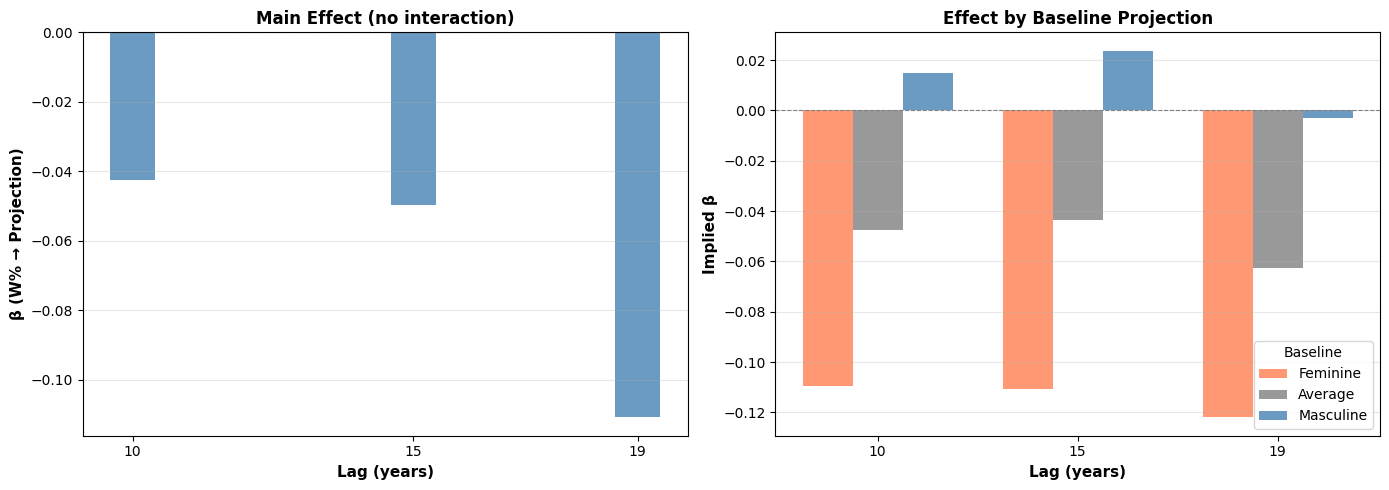


INTERPRETATION

This tests heterogeneity in the RI-CLPM framework (levels, not differences).

If β_interaction > 0:
  → Effect is MORE POSITIVE (less negative) for masculine-baseline professions
  → i.e., demographic feminization has SMALLER feminizing effect on 
    professions that were already semantically masculine

If β_interaction < 0:
  → Effect is MORE NEGATIVE for masculine-baseline professions
  → i.e., demographic feminization has LARGER feminizing effect on
    traditionally masculine professions

Either way, the MAIN effect β(W%) should remain negative if the core
finding holds: higher past W% → more feminine current projection.



In [20]:
# Heterogeneity test within RI-CLPM framework

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

print("=" * 70)
print("RI-CLPM HETEROGENEITY TEST: Does baseline moderate the W% → Projection effect?")
print("=" * 70)

# Get profession-level baseline projection (time-averaged)
prof_baseline = panel_df.groupby('profession')['projection'].mean()
panel_het = panel_df.copy()
panel_het['baseline_proj'] = panel_het['profession'].map(prof_baseline)
panel_het['baseline_proj_z'] = (panel_het['baseline_proj'] - panel_het['baseline_proj'].mean()) / panel_het['baseline_proj'].std()

# Sort and create lagged variables
panel_het = panel_het.sort_values(['profession', 'year']).copy()

# Test at a few key lags
test_lags = [10, 15, 19]

results_het = []

for lag_k in test_lags:
    # Create lagged predictors
    panel_het[f'women_pct_lag{lag_k}'] = panel_het.groupby('profession')['women_pct'].shift(lag_k)
    panel_het[f'projection_lag{lag_k}'] = panel_het.groupby('profession')['projection'].shift(lag_k)
    
    # Interaction term
    panel_het[f'wp_lag{lag_k}_x_base'] = panel_het[f'women_pct_lag{lag_k}'] * panel_het['baseline_proj_z']
    
    df_k = panel_het.dropna(subset=[f'women_pct_lag{lag_k}', f'projection_lag{lag_k}']).copy()
    
    if len(df_k) < 50:
        continue
    
    # Model without interaction
    formula_main = f"projection ~ projection_lag{lag_k} + women_pct_lag{lag_k}"
    
    # Model with interaction
    formula_het = f"projection ~ projection_lag{lag_k} + women_pct_lag{lag_k} + wp_lag{lag_k}_x_base"
    
    try:
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=ConvergenceWarning)
            
            # Main effects model
            model_main = smf.mixedlm(formula_main, data=df_k, groups=df_k["profession"])
            result_main = model_main.fit(disp=False)
            
            # Heterogeneous effects model
            model_het = smf.mixedlm(formula_het, data=df_k, groups=df_k["profession"])
            result_het = model_het.fit(disp=False)
        
        # Extract coefficients
        beta_main = result_main.fe_params[f'women_pct_lag{lag_k}']
        p_main = result_main.pvalues[f'women_pct_lag{lag_k}']
        
        beta_wp = result_het.fe_params[f'women_pct_lag{lag_k}']
        beta_int = result_het.fe_params[f'wp_lag{lag_k}_x_base']
        p_wp = result_het.pvalues[f'women_pct_lag{lag_k}']
        p_int = result_het.pvalues[f'wp_lag{lag_k}_x_base']
        
        results_het.append({
            'lag': lag_k,
            'n': len(df_k),
            'beta_main': beta_main,
            'p_main': p_main,
            'beta_wp': beta_wp,
            'p_wp': p_wp,
            'beta_int': beta_int,
            'p_int': p_int,
        })
        
        print(f"\n{'─' * 70}")
        print(f"Lag {lag_k} (n = {len(df_k)})")
        print(f"{'─' * 70}")
        
        print(f"\n  Main effects model:")
        print(f"    β(W%_lag{lag_k}): {beta_main:+.5f} (p = {p_main:.4f})")
        
        print(f"\n  Heterogeneous effects model:")
        print(f"    β(W%_lag{lag_k}):              {beta_wp:+.5f} (p = {p_wp:.4f})")
        print(f"    β(W%_lag{lag_k} × baseline_z): {beta_int:+.5f} (p = {p_int:.4f})")
        
        # Implied effects at different baselines
        print(f"\n  Implied β at different baselines:")
        for z, label in [(-1, "Feminine (-1 SD)"), (0, "Average"), (1, "Masculine (+1 SD)")]:
            implied_beta = beta_wp + beta_int * z
            print(f"    {label:<20}: β = {implied_beta:+.5f}")
        
        if p_int < 0.05:
            print(f"\n  ✓ Significant heterogeneity (p = {p_int:.4f})")
        else:
            print(f"\n  ✗ No significant heterogeneity (p = {p_int:.4f})")
            
    except Exception as e:
        print(f"  Lag {lag_k}: failed ({e})")

# Summary visualization
if results_het:
    results_df = pd.DataFrame(results_het)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: Main effect β across lags
    ax = axes[0]
    ax.bar(results_df['lag'], results_df['beta_main'], color='steelblue', alpha=0.8)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Lag (years)', fontsize=11, fontweight='bold')
    ax.set_ylabel('β (W% → Projection)', fontsize=11, fontweight='bold')
    ax.set_title('Main Effect (no interaction)', fontsize=12, fontweight='bold')
    ax.set_xticks(results_df['lag'])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Right: Implied β at different baselines
    ax = axes[1]
    width = 0.25
    x = np.arange(len(results_df))
    
    for i, (z, label, color) in enumerate([(-1, 'Feminine', 'coral'), 
                                            (0, 'Average', 'gray'), 
                                            (1, 'Masculine', 'steelblue')]):
        implied = results_df['beta_wp'] + results_df['beta_int'] * z
        ax.bar(x + (i - 1) * width, implied, width=width, label=label, color=color, alpha=0.8)
    
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Lag (years)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Implied β', fontsize=11, fontweight='bold')
    ax.set_title('Effect by Baseline Projection', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(results_df['lag'])
    ax.legend(title='Baseline')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

# Interpretation
print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)
print("""
This tests heterogeneity in the RI-CLPM framework (levels, not differences).

If β_interaction > 0:
  → Effect is MORE POSITIVE (less negative) for masculine-baseline professions
  → i.e., demographic feminization has SMALLER feminizing effect on 
    professions that were already semantically masculine

If β_interaction < 0:
  → Effect is MORE NEGATIVE for masculine-baseline professions
  → i.e., demographic feminization has LARGER feminizing effect on
    traditionally masculine professions

Either way, the MAIN effect β(W%) should remain negative if the core
finding holds: higher past W% → more feminine current projection.
""")